# feature_descriptors.py
# Educational Python script demonstrating SIFT, SURF, and ORB feature detection & description
# using OpenCV in Python.
#
# Important notes (as of 2025–2026):
#   • SIFT  → fully available in main OpenCV (patent expired ~2020–2021)
#   • ORB   → always free and patent-free, very fast
#   • SURF  → still patented / non-free in most distributions
#             Usually requires compiling OpenCV with OPENCV_ENABLE_NONFREE=ON
#             and including opencv_contrib modules.
#             → Many pre-built pip packages (opencv-python) do NOT include SURF.
#             → If SURF fails → comment it out or use ORB/SIFT instead for teaching.
#
# Requirements:
#   pip install opencv-python matplotlib numpy
#   (for SURF you may need custom build → most students use SIFT + ORB)



In [2]:
!pip install opencv-python matplotlib numpy

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_and_prepare_image(image_path):
    img_color = cv2.imread(image_path)
    if img_color is None:
        raise FileNotFoundError(f"Cannot load image: {image_path}")
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    return img_color, img_gray

def detect_and_compute_sift(gray_img):
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray_img, None)
    return keypoints, descriptors

def detect_and_compute_orb(gray_img, nfeatures=1500):
    orb = cv2.ORB_create(nfeatures=nfeatures)
    keypoints, descriptors = orb.detectAndCompute(gray_img, None)
    return keypoints, descriptors

def detect_and_compute_surf(gray_img):
    try:
        surf = cv2.xfeatures2d.SURF_create()
        keypoints, descriptors = surf.detectAndCompute(gray_img, None)
        return keypoints, descriptors
    except AttributeError:
        print("SURF is not available in this OpenCV build (patented / non-free).")
        return [], None
    except cv2.error as e:
        print("SURF error:", e)
        return [], None

def draw_keypoints(img_color, keypoints, title="Keypoints"):
    img_with_kp = cv2.drawKeypoints(
        img_color,
        keypoints,
        None,
        color=(0, 255, 0),
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

def drawMatches(img1, kp1, img2, kp2, matches):
    # Create a new output image that concatenates the two input images
    rows1 = img1.shape[0]
    cols1 = img1.shape[1]
    rows2 = img2.shape[0]
    cols2 = img2.shape[1]

    # Create a new image with enough space to fit both images horizontally
    out = np.zeros((max(rows1, rows2), cols1 + cols2, 3), dtype='uint8')
    out[:rows1, :cols1] = img1
    out[:rows2, cols1:cols1 + cols2] = img2

    # Loop over all the matches
    for m in matches:
        # Draw a line connecting the two keypoints
        img1_idx = m.queryIdx
        img2_idx = m.trainIdx

        # Get the keypoint coordinates
        pt1 = (int(kp1[img1_idx].pt[0]), int(kp1[img1_idx].pt[1]))
        pt2 = (int(kp2[img2_idx].pt[0]) + cols1, int(kp2[img2_idx].pt[1]))

        # Draw the line
        cv2.line(out, pt1, pt2, (0, 255, 0), 2)

    # Display the output image
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


In [3]:
def feature_matching(img1_path, img2_path):
    # Load and prepare images
    img1_color, img1_gray = load_and_prepare_image(img1_path)
    img2_color, img2_gray = load_and_prepare_image(img2_path)

    # Detect and compute descriptors
    kp1, des1 = detect_and_compute_orb(img1_gray)
    kp2, des2 = detect_and_compute_orb(img2_gray)

    # BFMatcher with default params
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

    # Match descriptors
    matches = bf.match(des1, des2)

    # Sort matches by distance (ascending)
    matches = sorted(matches, key=lambda x: x.distance)

    # Apply ratio test
    good_matches = []
    for m, n in zip(matches[:-1], matches[1:]):
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    # Draw matches
    drawMatches(img1_color, kp1, img2_color, kp2, good_matches)


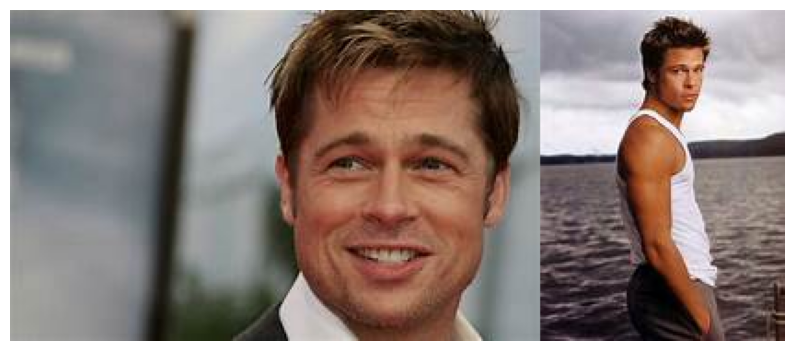

In [4]:
img1_path = r"C:\Users\VIDIT\Desktop\img.jpg"  # Replace with actual image path
img2_path = r"C:\Users\VIDIT\Desktop\img1.jpg"  # Replace with actual image path
feature_matching(img1_path, img2_path)

Images loaded successfully

Computing SIFT...


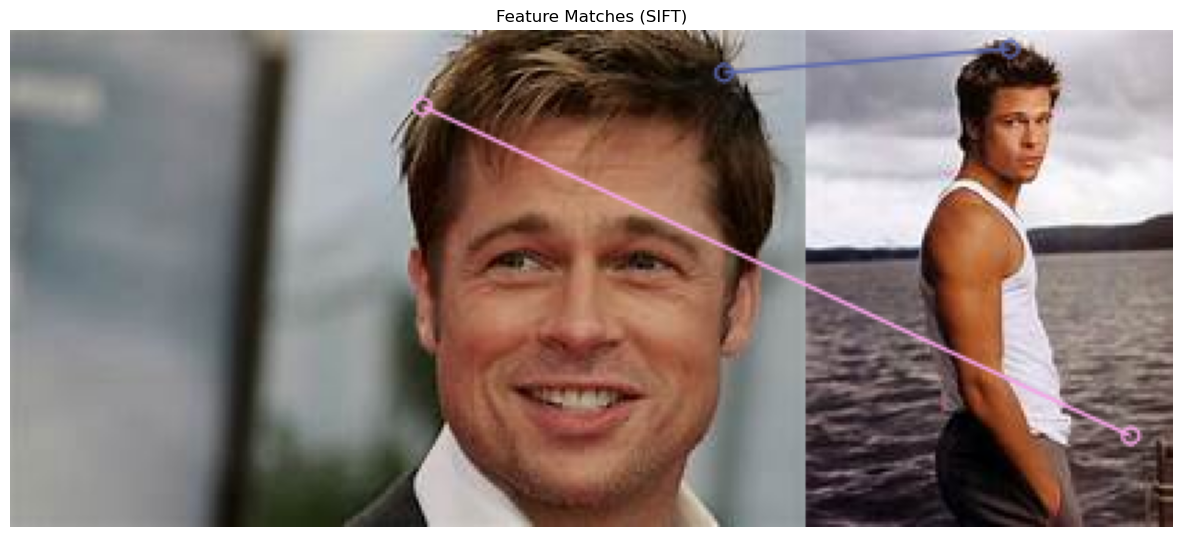

SIFT → Good Matches: 2
SIFT → Matching Score: 0.014

Computing ORB...


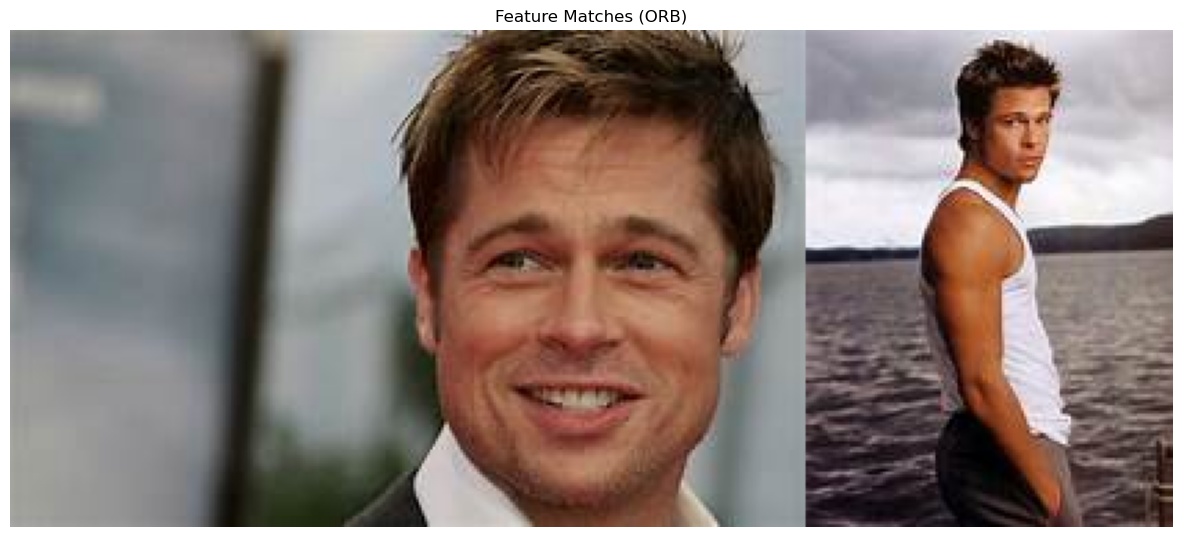

ORB → Good Matches: 0
ORB → Matching Score: 0.000

Computing SURF...
SURF not available. Using ORB instead.
SURF not available. Using ORB instead.


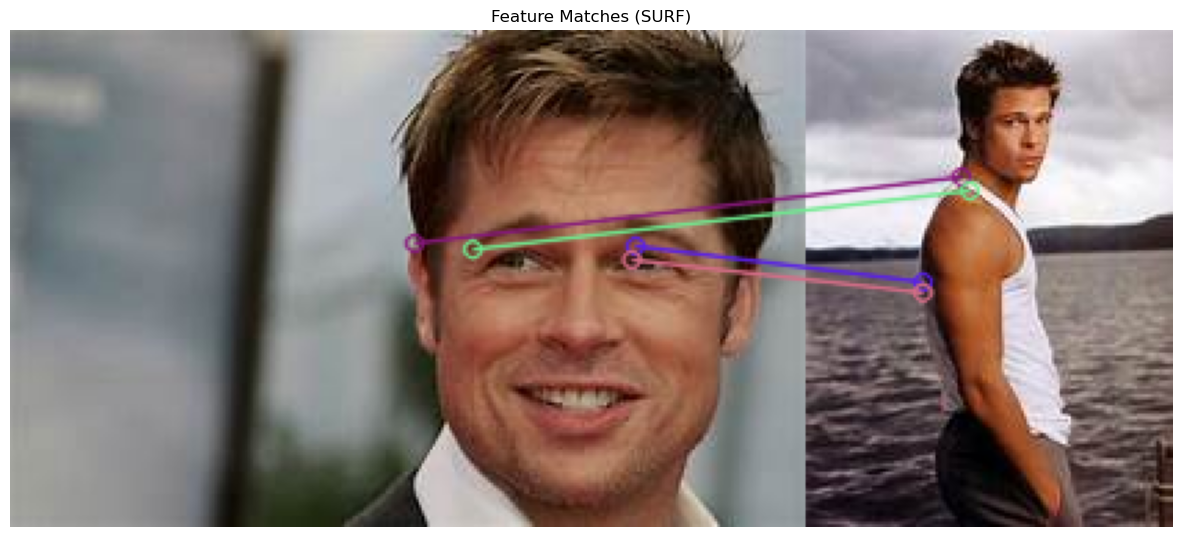

SURF → Good Matches: 4
SURF → Matching Score: 0.014


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# =====================================================
# IMAGE LOADING
# =====================================================

def load_and_prepare_image(image_path):
    img_color = cv2.imread(image_path)
    if img_color is None:
        raise FileNotFoundError(f"Cannot load image: {image_path}")

    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    return img_color, img_gray


# =====================================================
# FEATURE DETECTORS
# =====================================================

def detect_and_compute_sift(gray_img):
    sift = cv2.SIFT_create()
    return sift.detectAndCompute(gray_img, None)


def detect_and_compute_orb(gray_img, nfeatures=1500):
    orb = cv2.ORB_create(nfeatures=nfeatures)
    return orb.detectAndCompute(gray_img, None)


def detect_and_compute_surf(gray_img):
    try:
        surf = cv2.xfeatures2d.SURF_create()
        return surf.detectAndCompute(gray_img, None)
    except:
        print("SURF not available. Using ORB instead.")
        return detect_and_compute_orb(gray_img)


# =====================================================
# MATCHING
# =====================================================

def match_features(img1, img2, kp1, des1, kp2, des2, detector_type='SIFT'):

    if des1 is None or des2 is None:
        print("Descriptors missing.")
        return 0

    if detector_type in ['SIFT', 'SURF']:
        bf = cv2.BFMatcher(cv2.NORM_L2)
    else:
        bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    img_matches = cv2.drawMatches(
        img1, kp1, img2, kp2, good, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(15, 8))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title(f"Feature Matches ({detector_type})")
    plt.axis('off')
    plt.show()

    return len(good)


# =====================================================
# SCORING
# =====================================================

def compute_matching_score(num_good_matches, kp1, kp2):
    if len(kp1) == 0 or len(kp2) == 0:
        return 0.0
    return num_good_matches / min(len(kp1), len(kp2))


# =====================================================
# MAIN
# =====================================================

def main():

    # 🔥 CHANGE THESE PATHS TO YOUR IMAGE PATHS
    image_path1 = r"C:\Users\VIDIT\Desktop\img.jpg"
    image_path2 = r"C:\Users\VIDIT\Desktop\img1.jpg"

    if not os.path.exists(image_path1) or not os.path.exists(image_path2):
        print("One or both image paths are incorrect.")
        return

    color_img1, gray_img1 = load_and_prepare_image(image_path1)
    color_img2, gray_img2 = load_and_prepare_image(image_path2)

    print("Images loaded successfully\n")

    # -------- SIFT --------
    print("Computing SIFT...")
    kp1, des1 = detect_and_compute_sift(gray_img1)
    kp2, des2 = detect_and_compute_sift(gray_img2)

    sift_good = match_features(color_img1, color_img2, kp1, des1, kp2, des2, 'SIFT')
    sift_score = compute_matching_score(sift_good, kp1, kp2)

    print(f"SIFT → Good Matches: {sift_good}")
    print(f"SIFT → Matching Score: {sift_score:.3f}\n")

    # -------- ORB --------
    print("Computing ORB...")
    kp1, des1 = detect_and_compute_orb(gray_img1, 2000)
    kp2, des2 = detect_and_compute_orb(gray_img2, 2000)

    orb_good = match_features(color_img1, color_img2, kp1, des1, kp2, des2, 'ORB')
    orb_score = compute_matching_score(orb_good, kp1, kp2)

    print(f"ORB → Good Matches: {orb_good}")
    print(f"ORB → Matching Score: {orb_score:.3f}\n")

    # -------- SURF --------
    print("Computing SURF...")
    kp1, des1 = detect_and_compute_surf(gray_img1)
    kp2, des2 = detect_and_compute_surf(gray_img2)

    surf_good = match_features(color_img1, color_img2, kp1, des1, kp2, des2, 'SURF')
    surf_score = compute_matching_score(surf_good, kp1, kp2)

    print(f"SURF → Good Matches: {surf_good}")
    print(f"SURF → Matching Score: {surf_score:.3f}")


if __name__ == "__main__":
    main()
